DAMO630 Advanced Data Analytics 
##### Assignment 1 - Group 2
# TASK1
## Exploratory Analysis of Real Dataset

In [0]:
# import libraries
import numpy as np
import pandas as pd

# Load Heathcare dataset
df = pd.read_csv("HealthInsurance.csv")

# Check shape of the dataset
print("Rows, columns:", df.shape,"\n")

# Check row names, data types and null values
print(">>> Healthcare df Info:")
print(df.info(),"\n")

# Check df basic stats (numerical columns)
print(">>> Healthcare df stats:\n", df.describe(),"\n")

# Check basic values and distribution of categorical columns
print(">>> Categorical columns:")
print(df.select_dtypes(include=['object']).describe().T,"\n")

# Check df sample
print(">>> df Sample (head):\n", df.head(5))


Rows, columns: (8802, 12) 

>>> Healthcare df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8802 entries, 0 to 8801
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rownames   8802 non-null   int64 
 1   health     8802 non-null   object
 2   age        8802 non-null   int64 
 3   limit      8802 non-null   object
 4   gender     8802 non-null   object
 5   insurance  8802 non-null   object
 6   married    8802 non-null   object
 7   selfemp    8802 non-null   object
 8   family     8802 non-null   int64 
 9   region     8802 non-null   object
 10  ethnicity  8802 non-null   object
 11  education  8802 non-null   object
dtypes: int64(3), object(9)
memory usage: 825.3+ KB
None 

>>> Healthcare df stats:
           rownames          age       family
count  8802.000000  8802.000000  8802.000000
mean   4401.500000    38.936833     3.093501
std    2541.062868    11.110823     1.559633
min       1.000000    18.00000

### Dataset Overview

The dataset contains 8,802 records with 12 columns, providing a mix of demographic and healthcare-related information. The columns include both numerical features (e.g., age, family size) and categorical variables (e.g., health status, gender, insurance, region). 

Key statistics:
- There are 3 numerical coluns **Age**, **Family size** and **rownames**.
- **row names**: Seem to be a simple index. However it can also be a ID. Either way it should be ignored for numeric analysis and handle carefully for privacy purposes if an ID.
- Categorical variables like **health** and **insurance** are predominantly "yes", with a few exceptions in categories like **region** and **ethnicity**, which represent regional and cultural diversity within the sample. 

This overview provides an initial look at the dataset’s structure, which will be further explored through visualizations to better understand the distributions and relationships of the categorical features.


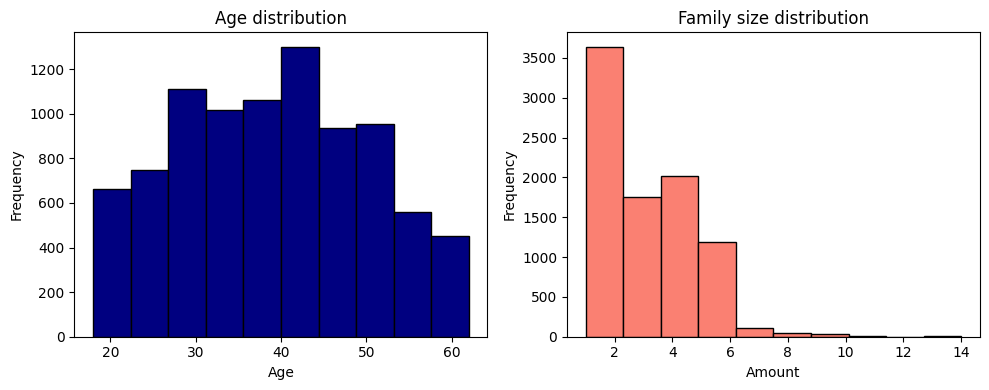

In [0]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Distrubutions of numerical features
# Age distribution
axes[0].hist(df['age'], color='navy', edgecolor='black')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Family size distribution
axes[1].hist(df['family'], color='salmon', edgecolor='black')
axes[1].set_title('Family size distribution')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("distributions_numerical.png")

###1. Feature distributions
#### Numerical features

**Age**: The mean age is about 39, with a spread from 18 to 62. The interquartile range (IQR) is between 30 and 48, which suggests a fairly balanced distribution in terms of age. Visualization of the distribution confirm it's roughly normally distributed.

**Family Size:** The mean family size is 3, and the maximum value is 14. Distribution being skewed to the left makes sense, however maximum value of 14 indicates a possible outlier, which should be checked before creating the synthetic data.


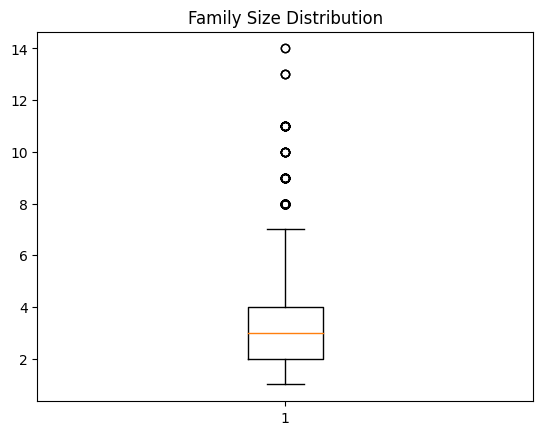

In [0]:
# Boxplot of Family Size
plt.boxplot(df['family'])
plt.title('Family Size Distribution')
plt.savefig("boxplots_familysize.png")
plt.show()


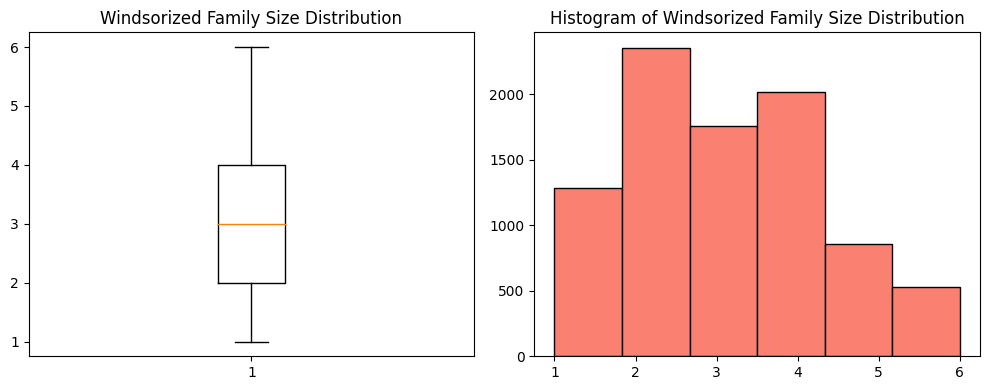

In [0]:
## Handling the outliers in the family column

# Backup of the original dataset
df_real = df.copy()

# Calculate the upper bound based on a chosen percentile ( 95th percentile)
upper_limit = np.percentile(df['family'], 95) 

# Apply Windsorization by replacing values above the upper limit
df['family'] = np.where(df['family'] > upper_limit, upper_limit, df['family'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Check the distribution after Windsorizing
axes[0].boxplot(df['family'])
axes[0].set_title('Windsorized Family Size Distribution')

# Family size distribution
axes[1].hist(df['family'], color='salmon',  bins=6, edgecolor='black')
axes[1].set_title('Histogram of Windsorized Family Size Distribution')
plt.savefig("windsorized_familysize.png")
plt.tight_layout()



#### Windsorization of Family Size Outliers

To address the impact of extreme family size values (e.g., greater than 7 members), we applied a Windsorization technique. This involves capping the outliers at the 95th percentile to reduce their influence on subsequent analyses. This ensures that the data remains realistic while avoiding the skewing effects of rare, extreme values that could distort statistical modeling or synthetic data generation later. The adjusted family size distribution is now more balanced and better suited for further analysis.


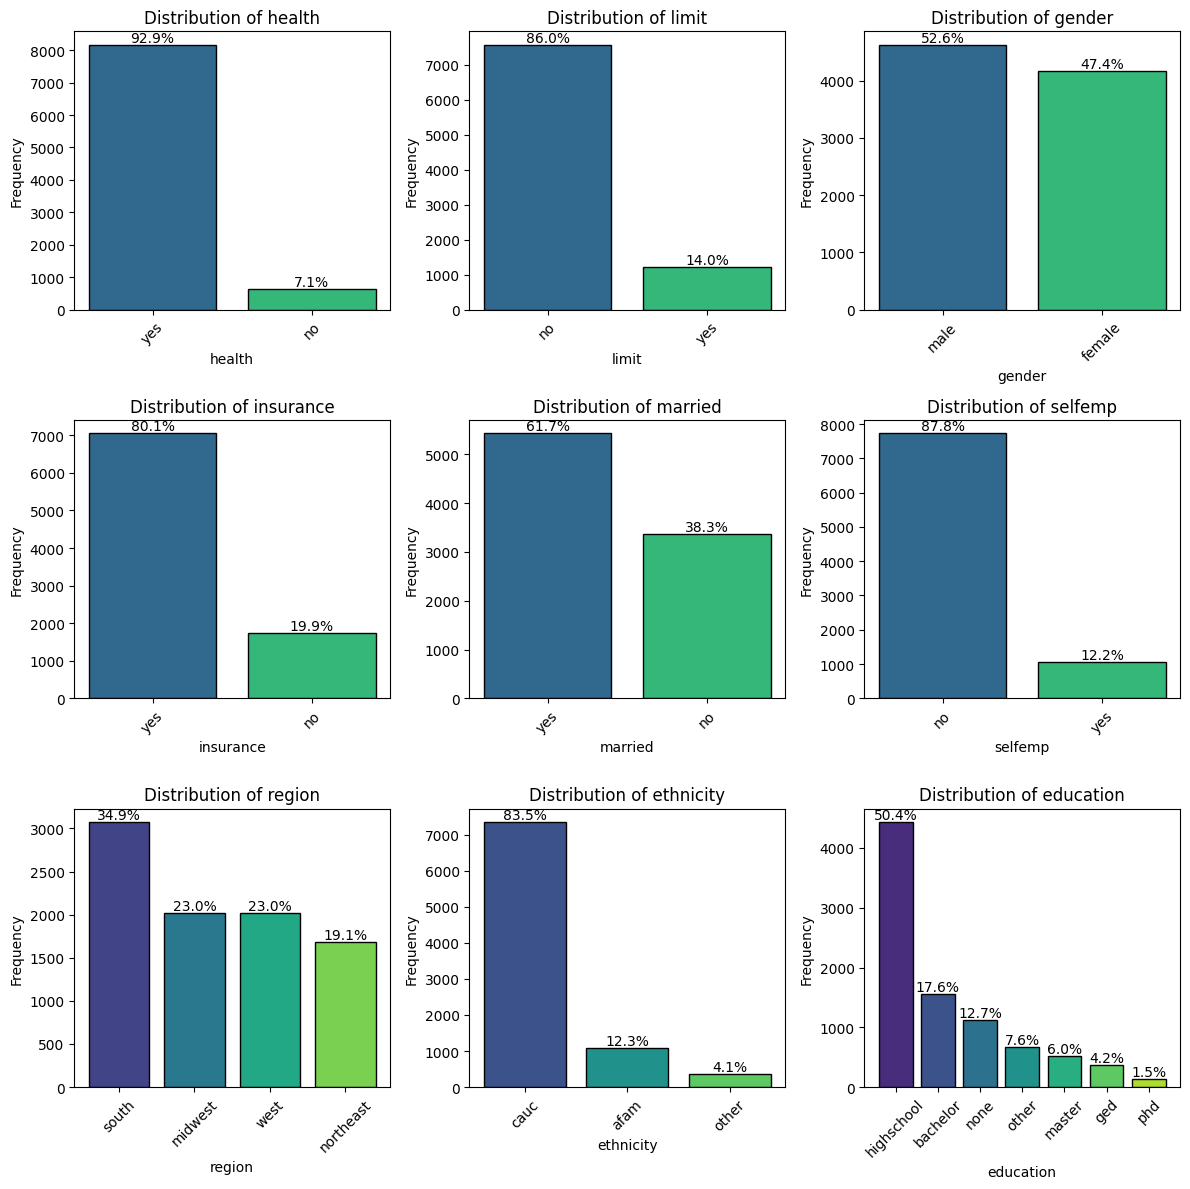

In [0]:
import seaborn as sns

# Create a grid for subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Loop over each categorical column
for i, col in enumerate(df.select_dtypes(include=['object']).columns):
    # Get the value counts of the categorical column
    value_counts = df[col].value_counts()

    # Choose a different color palette for each category
    colors = sns.color_palette("viridis", len(value_counts))

    # Plot bar chart
    axes[i//3, i%3].bar(value_counts.index, value_counts.values, color=colors, edgecolor='black')

    # Calculate the percentage for each category
    total = value_counts.sum()
    percentages = (value_counts / total) * 100

    # Add percentage labels on top of bars
    for j, value in enumerate(value_counts.values):
        axes[i//3, i%3].text(value_counts.index[j], value + 0.05, f'{percentages.iloc[j]:.1f}%', 
                              ha='center', va='bottom', fontsize=10)

    # Set plot titles and labels
    axes[i//3, i%3].set_title(f'Distribution of {col}')
    axes[i//3, i%3].set_xlabel(col)
    axes[i//3, i%3].set_ylabel('Frequency')

    # Rotate x-axis labels if they overlap
    axes[i//3, i%3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("distributions_categorical.png")
plt.show()



### Distribution of Categorical Variables

The plots above show the distribution of various categorical variables within the dataset. Key observations include:
- **Health**: The vast majority (92%) of individuals report being in good health.
- **Limit**: Most individuals (86%) do not have any significant limits on their activities.
- **Gender**: The dataset has a balanced gender distribution, with 47.4% females and 52.6% males.
- **Insurance**: A high percentage (80%) of individuals have insurance coverage.
- **Marital Status**: 61.7% of the individuals are married, while 38.3% are not.
- **Self-Employment**: A large proportion (87.8%) of individuals are not self-employed.
- **Region**: The majority (34.9%) of individuals are from the South region, followed by the Midwest, West, and Northeast regions.
- **Ethnicity**: The majority of individuals identify as Caucasian (83.5%).
- **Education**: The largest group (50.4%) holds a high school diploma, with a smaller percentage having bachelor’s, master’s, or other higher education qualifications.

These distributions provide insight into the demographics of the dataset and are useful for understanding the population structure before proceeding with further analysis.


### 2. Privacy-Sensitive Attributes

In this dataset, there are several features that can be considered **privacy-sensitive**. These features may expose personal, financial, or health-related information, which could lead to potential risks such as discrimination or breach of privacy.

#### Suggested Privacy-Sensitive Features:

- **Health**: This feature reflects an individual’s health status. It could indicate whether the person has a medical condition or is in good health, which is highly sensitive. Such information can be used to discriminate against individuals in areas like insurance or employment.

- **Limit**: The "limit" column could reveal whether an individual has restricted access to healthcare services, which might suggest financial challenges or specific health conditions. This information is considered sensitive as it could affect an individual’s ability to receive medical care.

- **Ethnicity**: Ethnicity is a sensitive attribute that could be used for discriminatory practices. Revealing ethnicity can lead to bias in decision-making or unfair treatment based on cultural or racial background. It should be handled carefully to prevent any kind of discrimination.

- **Insurance**: The "insurance" feature can indicate an individual’s access to healthcare services, which might also suggest their financial stability or vulnerabilities. This data could be misused to profile or exclude certain groups of people, especially in terms of health coverage.

- **Rownames**: This column seems to serve as an index for the dataset, but if it is used as an **ID** for individuals, it could become sensitive information. In such a case, it should be handled with extra care to avoid potential re-identification risks.

#### Recommendation:

These privacy-sensitive attributes should be **clearly labeled** in any dataset to ensure that proper protections are applied when working with the data. In this case, no direct personal information is present, which lowers the likelihood of re-identifying individuals. However, privacy-sensitive information (such as health status, ethnicity, and insurance) must still be carefully handled, especially when generating synthetic data, ensuring the generated data maintains statistical similarity without compromising individual privacy and the utility of the data for research or collaboration purposes.



<Axes: >

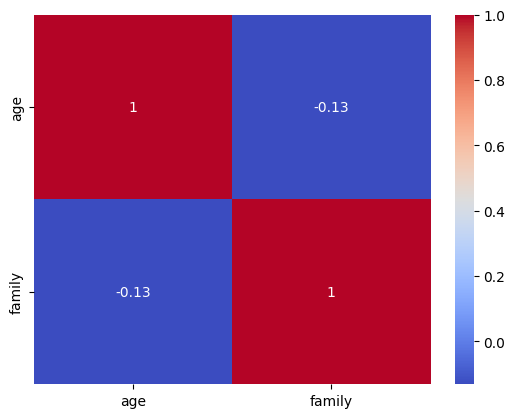

In [0]:
correlation_matrix = df[['age', 'family']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


The correlation matrix for the numerical features (age and family size) shows that the correlation coefficient is -0.13, which indicates a weak negative correlation between these two features. This means that, as age increases, family size tends to slightly decrease, but the relationship is not strong.

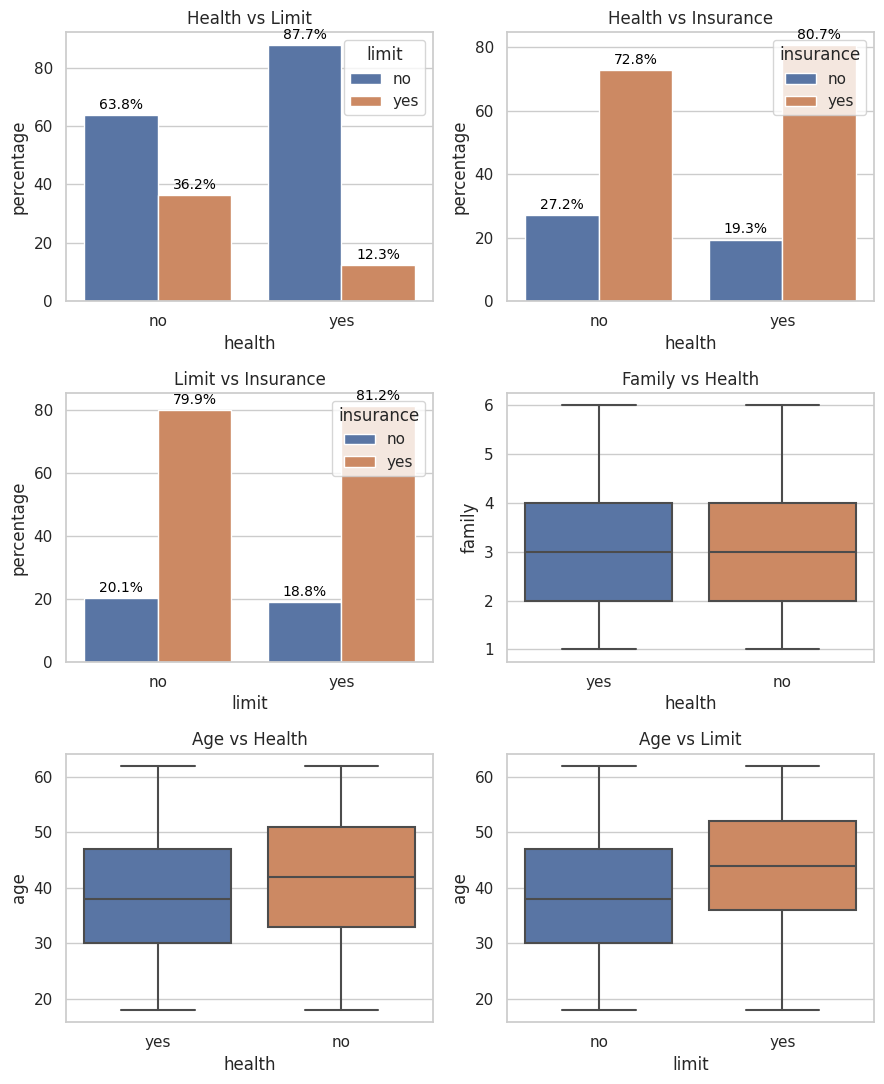

In [0]:
# Set up the seaborn style
sns.set(style="whitegrid")

# Function to calculate percentages, plot, and add labels
def plot_percentage(ax, data, x, hue, title):
    # Calculate the count of each combination
    count_data = data.groupby([x, hue]).size().reset_index(name='count')
    
    # Calculate the total count for each x category
    total_counts = count_data.groupby(x)['count'].transform('sum')
    
    # Calculate the percentage
    count_data['percentage'] = (count_data['count'] / total_counts) * 100
    
    # Use barplot instead of countplot to plot percentages
    sns.barplot(x=x, y='percentage', hue=hue, data=count_data, ax=ax)
    ax.set_title(title)
    
    # Add labels to each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 1, f'{height:.1f}%', 
                ha="center", va="bottom", fontsize=10, color='black')

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(9, 11))

# Categorical x Categorical (Health vs Limit)
plot_percentage(axes[0, 0], df, 'health', 'limit', 'Health vs Limit')

# Categorical x Categorical (Health vs Insurance)
plot_percentage(axes[0, 1], df, 'health', 'insurance', 'Health vs Insurance')

# Categorical x Categorical (Limit vs Insurance)
plot_percentage(axes[1, 0], df, 'limit', 'insurance', 'Limit vs Insurance')

# Numerical x Categorical (Family vs Health)
sns.boxplot(x='health', y='family', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Family vs Health')

# Numerical x Categorical (Age vs Health)
sns.boxplot(x='health', y='age', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Age vs Health')

# Numerical x Categorical (Age vs Limit)
sns.boxplot(x='limit', y='age', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Age vs Limit')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()



### 3. Correlation and Distribution of Key Features

The following plots show the relationships between key categorical features. Percentages are used instead of raw counts due to the **imbalance in the dataset**.

##### Health x Limitations
- **36.2%** of people with poor health face limitations on their coverage, while only **12.3%** of healthy individuals report similar coverage limitations.

##### Health x Insurance
- **27.2%** of people with poor health lack insurance, compared to **19.3%** for healthy individuals.

##### Limitations x Insurance
- **20.1%** of people without limitations also lack insurance, while **18.8%** of people with limitations do not have insurance. The rates are relatively similar.

##### Family x Health
- Family size shows no significant difference between individuals with or without health issues.

##### Age vs Health
- Individuals with poor health (marked "no" in the health column) tend to be slightly older, with a median age around **40**. In contrast, those with good health (marked "yes") are generally younger, with a median age of about **30**. 
- The age distribution is wider among those with poor health, indicating a broader age range.

##### Age vs Limitations
- The median age for individuals with a limitation (marked "yes" in the limit column) is higher, around **50**, compared to those without limitations (marked "no"), whose median age is approximately **40**. 
- Additionally, the age range for individuals with limitations is slightly wider, suggesting a greater diversity in ages within this group.



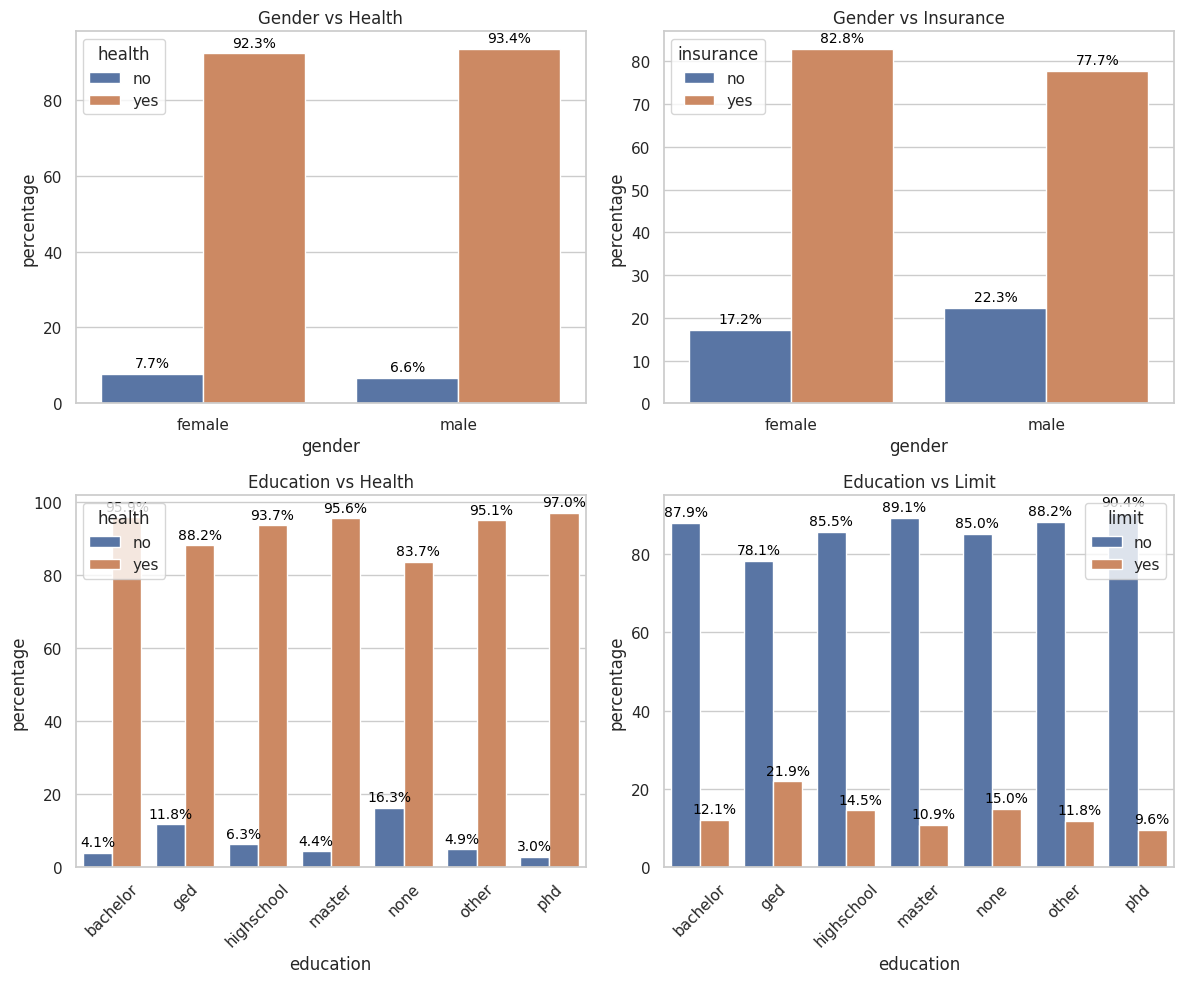

In [0]:
# Function to calculate percentages, plot, and add labels
def plot_percentage_with_labels(ax, data, x, hue, title):
    # Calculate the count of each combination
    count_data = data.groupby([x, hue]).size().reset_index(name='count')
    
    # Calculate the total count for each x category
    total_counts = count_data.groupby(x)['count'].transform('sum')
    
    # Calculate the percentage
    count_data['percentage'] = (count_data['count'] / total_counts) * 100
    
    # Use barplot instead of countplot to plot percentages
    sns.barplot(x=x, y='percentage', hue=hue, data=count_data, ax=ax)
    ax.set_title(title)
    
    # Add labels to each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 1, f'{height:.1f}%', 
                ha="center", va="bottom", fontsize=10, color='black')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gender and Health/Insurance (Categorical x Categorical)
# Gender vs Health
plot_percentage_with_labels(axes[0, 0], df, 'gender', 'health', 'Gender vs Health')

# Gender vs Insurance
plot_percentage_with_labels(axes[0, 1], df, 'gender', 'insurance', 'Gender vs Insurance')

# Education and Health/Limit (Categorical x Categorical)
# Education vs Health
plot_percentage_with_labels(axes[1, 0], df, 'education', 'health', 'Education vs Health')
axes[1, 0].tick_params(axis='x', rotation=45)

# Education vs Limit
plot_percentage_with_labels(axes[1, 1], df, 'education', 'limit', 'Education vs Limit')
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


##### Gender vs Health
  - Both genders show a very small percentage of individuals reporting poor health, but females have a slightly higher percentage of poor health compared to males.

##### Gender vs Insurance
  - Males have a higher percentage of uninsured individuals compared to females, with **22.3%** lacking insurance x **17.2%** for women.

##### Education vs Health
  - **Bachelor's degree holders** show the highest percentage of good health at **88.2%**, while **11.8%** report poor health.
  - **PhD holders** report the lowest percentage of poor health, with **97%** of individuals in good health.
  - Individuals with less formal education (e.g., high school, GED) report higher rates of poor health.
  - People with no education also show a relatively higher rate of poor health (**16.3%**).

##### Education vs Limitations
  - **PhD holders** report the lowest percentage of limitations (**9.6%**), while **90.4%** have no limitations.
  - People with a **GED** show the highest percentage of limitations, with **21.9%** experiencing coverage restrictions.
  - **Bachelor's and Master's degree holders** show a relatively low percentage of limitations, with **12.1%** and **15.0%**, respectively.

These visual insights suggest that gender and education level have significant impacts on both health status and insurance coverage, with males being more likely to lack insurance, and individuals with lower levels of education reporting poorer health and more limitations in coverage.


In [0]:
from scipy.stats import f_oneway

# Identify categorical features with dtype 'object'
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Perform ANOVA test with age
num_feature = 'age'
print(f"ANOVA Test to compare 'age' across different features:", "\n")
for cat_feature in cat_features:
    groups = [df[df[cat_feature] == cat][num_feature] for cat in df[cat_feature].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"> for {cat_feature}: F-statistic={f_stat}, p-value={p_value}")
print("\n")
# Perform ANOVA test with family
num_feature = 'family'
print(f"ANOVA Test to compare 'family' across different features:", "\n")
for cat_feature in cat_features:
    groups = [df[df[cat_feature] == cat][num_feature] for cat in df[cat_feature].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"> for {cat_feature}: F-statistic={f_stat}, p-value={p_value}")

ANOVA Test to compare 'age' across different features: 

> for health: F-statistic=46.41844067403124, p-value=1.0178471767831708e-11
> for limit: F-statistic=223.47943188226714, p-value=6.439414731900341e-50
> for gender: F-statistic=0.028159460060402618, p-value=0.8667383366781805
> for insurance: F-statistic=205.3983998909922, p-value=4.564701450932144e-46
> for married: F-statistic=838.0400371334962, p-value=4.294321830496989e-176
> for selfemp: F-statistic=236.47734711051845, p-value=1.1127790957301952e-52
> for region: F-statistic=5.900178491860056, p-value=0.0005110914420536252
> for ethnicity: F-statistic=2.5534723010205904, p-value=0.07786867156122425
> for education: F-statistic=26.196639478078286, p-value=4.527895627384376e-31


ANOVA Test to compare 'family' across different features: 

> for health: F-statistic=1.4907982175538412, p-value=0.22212536535559704
> for limit: F-statistic=84.85448444789725, p-value=3.954140531083162e-20
> for gender: F-statistic=11.92369470293667

### ANOVA Test Highlights and Key Insights
ANOVA was applied to test the statistical conection between features, as both numerical variables, age and family size (post-Windsorization), exhibited a relatively normal distribution.

#### Age across Different Categories:
- **Health**: Significant difference in age between those with good and poor health (p-value < 0.05).
- **Limitations**: Age differs significantly between individuals with and without limitations (p-value < 0.05).
- **Gender**: No significant difference in age across genders (p-value > 0.05).
- **Insurance**: Significant age difference between insured and uninsured individuals (p-value < 0.05).
- **Marital Status**: Strong significant difference in age between married and unmarried individuals (p-value < 0.05).
- **Self-employment**: Significant age difference between self-employed and non-self-employed individuals (p-value < 0.05).
- **Education**: Significant difference in age across education levels (p-value < 0.05).

#### Family across Different Categories:
- **Health**: No significant difference in family size across health categories (p-value > 0.05).
- **Limitations**: Significant difference in family size between those with and without limitations (p-value < 0.05).
- **Gender**: Significant difference in family size between males and females (p-value < 0.05).
- **Insurance**: Significant difference in family size between insured and uninsured individuals (p-value < 0.05).
- **Marital Status**: Strong significant difference in family size between married and unmarried individuals (p-value < 0.05).
- **Self-employment**: No significant difference in family size between self-employed and non-self-employed individuals (p-value > 0.05).
- **Education**: Significant difference in family size across education levels (p-value < 0.05).

### Conclusion:
- **Age** shows significant differences across categories such as health, limitations, marital status, insurance, and employment, with some categories such as gender and ethnicity showing no significant differences.
- **Family size** has fewer significant associations, with marital status, insurance coverage, and education levels showing stronger relationships compared to factors like health or self-employment.

These results suggest that both age and family size are influenced by demographic factors such as marital status, insurance coverage, and education, while other variables like gender and self-employment do not exhibit strong associations.


In [0]:
import scipy.stats as stats

# List of categorical columns
categorical_columns = ['health', 'limit', 'gender', 'insurance', 'married', 'selfemp', 'region', 'ethnicity', 'education']

# Function to compute Cramér's V
def cramers_v(chi2, n, table):
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

# Initialize data structures for storing results
chi2_results = []
cramers_v_results = []

# For each pair of categorical variables, conduct the Chi-square test
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 != col2:  # Skip comparing the variable to itself
            # Create a contingency table
            contingency_table = pd.crosstab(df[col1], df[col2])

            # Perform Chi-square test
            chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

            # Calculate Cramér's V
            cramers_v_value = cramers_v(chi2, df.shape[0], contingency_table)

            # Store the results for Chi-square p-value and Cramér's V
            chi2_results.append([col1, col2, p])
            cramers_v_results.append([col1, col2, cramers_v_value])

# Convert results to DataFrames for easy display
chi2_df = pd.DataFrame(chi2_results, columns=["Variable 1", "Variable 2", "Chi-square p-value"])
cramers_v_df = pd.DataFrame(cramers_v_results, columns=["Variable 1", "Variable 2", "Cramérs V"])

# Display the results using Databricks' display function
display(chi2_df)  # Display the Chi-square p-values table
display(cramers_v_df)  # Display the Cramér's V table



Variable 1,Variable 2,Chi-square p-value
health,limit,3.209158089336857E-62
health,gender,0.04165881404728251
health,insurance,2.4602505838864183E-6
health,married,0.4309035032532669
health,selfemp,0.2528047396056658
health,region,0.009322232600361373
health,ethnicity,0.0028952780644983652
health,education,4.793897155943762E-39
limit,health,3.209158089336857E-62
limit,gender,0.4078966437597097


Variable 1,Variable 2,Cramérs V
health,limit,0.17743194468709775
health,gender,0.02171109288205369
health,insurance,0.050217948994998256
health,married,0.008395386010062006
health,selfemp,0.012189041969142817
health,region,0.036140568056985733
health,ethnicity,0.03644218986489064
health,education,0.14823380709164624
limit,health,0.17743194468709775
limit,gender,0.008821251272767379


### Chi-Square Test Insights and Conclusion

##### Key Insights:
- **Strong Associations**: Several variables, including **health, insurance, marital status, self-employment, ethnicity**, and **education**, show highly significant relationships with other features. These associations suggest that factors like health, marital status, and education level have a considerable impact on other socio-demographic aspects, such as insurance coverage and employment status.
  
- **Regional and Ethnic Variations**: **Region** and **ethnicity** appear to have strong associations with several variables, particularly **health**, **insurance**, and **education**, indicating that geographic and cultural factors play a significant role in shaping these outcomes.

- **Health and Insurance**: There is a particularly strong relationship between **health** and **insurance**, with individuals in poor health more likely to face challenges in securing insurance, further suggesting that health status is a critical determinant for coverage.

- **Non-Significant Associations**: Some variables, such as **health x self-employment** and **limit x gender**, do not exhibit significant relationships, indicating that self-employment and gender may not strongly influence certain outcomes like health or coverage limitations.

**Conclusion**: The Chi-square test results highlight the complex interrelationships between socio-demographic factors. While some variables, like **education** and **marital status**, show strong associations with other features, others, such as **self-employment** and **gender**, demonstrate less impact. These insights are essential for understanding how different factors, such as health, insurance, and region, intersect and influence broader societal trends.


### Cramér's V Test Insights and Conclusion

##### Key Insights:
- **Moderate Associations**: Some pairs of variables show moderate associations, particularly **health x limitations (V = 0.177)** and **health x education (V = 0.148)**. These moderate values suggest that these variables have a moderate relationship but are not strongly dependent on each other.
  
- **Low Associations**: Many of the variables show very weak associations, with values generally below 0.1. For example, **health x gender (V = 0.022)** and **limit x married (V = 0.002)**, indicating that these pairs are weakly related or not meaningfully correlated.

- **Strongest Relationship**: The strongest association in the dataset is between **insurance x education (V = 0.280)**, which suggests that education level has a notable impact on insurance coverage, with higher education possibly leading to better insurance access.

- **Ethnicity and Region**: Both **ethnicity x region (V = 0.159)** and **region x ethnicity (V = 0.159)** show stronger relationships compared to other variable pairs, highlighting that geographic and cultural factors likely influence multiple aspects of socio-demographic characteristics.

**Conclusion**: The Cramér's V test results indicate that while there are some moderate associations, many relationships between pairs of variables are weak. **Insurance** and **education** demonstrate a significant relationship, while associations involving **health**, **gender**, and **self-employment** tend to be weak. These results suggest that while certain variables have noticeable associations, many others have minimal influence on each other, indicating that socio-demographic factors operate independently in many cases.

### Final Comparison:

The Chi-Square test identifies significant associations but doesn’t quantify the strength of those relationships, making it more focused on identifying whether associations exist.

The Cramér's V test quantifies the strength of the relationships, revealing that while some associations are moderate, many are weak, offering a clearer picture of the strength and relevance of socio-demographic relationships.

# TASK 2
## Generating Synthetic Data 

In [0]:
# Reproducibility
np.random.seed(42)

# Original size
n_original = len(df)

# -------- STRATIFIED BOOTSTRAP --------
synthetic_parts = []

for health_class, group in df.groupby("health"):
    # proportion of each class
    prop = len(group) / n_original
    
    # sample same proportion with replacement
    n_samples = int(round(prop * n_original))
    
    boot_group = group.sample(n=n_samples, replace=True, random_state=42)
    synthetic_parts.append(boot_group)

bootstrap_df = pd.concat(synthetic_parts).reset_index(drop=True)

# -------- NOISE INJECTION (Numerical Only) --------
noise_scale = 0.05  # 5% of standard deviation

for col in ["age", "family"]:
    std = df[col].std()
    noise = np.random.normal(0, std * noise_scale, size=len(bootstrap_df))
    bootstrap_df[col] = bootstrap_df[col] + noise
    
# Keep realistic bounds (no negative and int for family)
bootstrap_df["age"] = bootstrap_df["age"].clip(lower=0)
bootstrap_df["family"] = bootstrap_df["family"].round().clip(lower=0)

bootstrap_df

,rownames,health,age,limit,gender,insurance,married,selfemp,family,region,ethnicity,education
0,1564,no,45.275945,no,female,yes,yes,yes,2.0,northeast,cauc,highschool
1,6330,no,42.923188,no,male,no,yes,no,6.0,south,cauc,none
2,3873,no,26.359818,no,female,no,yes,no,6.0,south,cauc,none
3,1674,no,41.846106,yes,female,yes,yes,no,5.0,south,cauc,master
4,886,no,27.869918,no,male,yes,yes,no,6.0,west,cauc,none
...,...,...,...,...,...,...,...,...,...,...,...,...
8797,2731,yes,26.498685,no,male,no,yes,no,2.0,south,cauc,highschool
8798,4106,yes,40.697869,yes,female,no,no,no,1.0,northeast,afam,none
8799,6238,yes,49.659824,no,female,yes,no,no,1.0,south,cauc,highschool
8800,5264,yes,19.546729,no,female,no,no,no,1.0,northeast,cauc,highschool


#### Method Applied - Stratified Bootstrapping

The dataset contains 2 numerical and 9 categorical variables, with strong imbalance in key features (e.g., 92.8% reporting good health). Because the dataset is predominantly categorical, preserving the joint distribution and multivariate relationships between variables is critical.

For this reason, a stratified bootstrapping approach was selected using health as the stratification variable. Bootstrapping preserves the original joint distribution, maintaining real-world dependencies such as health–insurance, region–ethnicity, and family–marital status. Stratifying on health ensures proportional representation of minority cases while avoiding the combinatorial explosion that would result from stratifying across all categorical variables, which would create many small strata and near-duplicate records.

Independent rule-based generation methods (e.g., Faker) were not appropriate because they assume full independence between variables, replicating marginal distributions but destroying structural relationships. Pure noise injection was also insufficient, as it only affects numerical variables and does not preserve categorical dependencies.

After resampling with replacement, mild Gaussian noise (5% of the original standard deviation) was injected into the numerical variables (age and family) to introduce limited variability while preserving their distributional properties. The synthetic dataset retained the original size (n = 8,802).

In [0]:
# Numerical Comparison 
# Summary Statistics Table
num_cols = ["age", "family"]

summary_real = df[num_cols].describe()
summary_synth = bootstrap_df[num_cols].describe()

summary_comparison = pd.concat(
    [summary_real.add_suffix("_real"),
     summary_synth.add_suffix("_synth")],
    axis=1
)

summary_comparison


,age_real,family_real,age_synth,family_synth
count,8802.000000,8802.000000,8802.000000,8802.000000
mean,38.936833,3.046353,38.781788,3.075778
std,11.110823,1.418108,11.109304,1.438449
min,18.000000,1.000000,16.853695,1.000000
25%,30.000000,2.000000,30.095822,2.000000
50%,39.000000,3.000000,38.566688,3.000000
75%,48.000000,4.000000,47.324886,4.000000
max,62.000000,6.000000,63.634984,6.000000


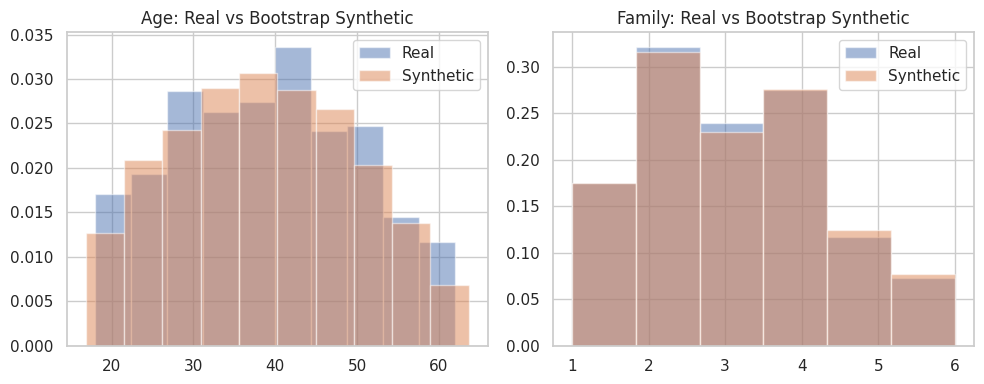

<Figure size 640x480 with 0 Axes>

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Age distribution comparison
axes[0].hist(df['age'], alpha=0.5, label="Real", density=True)
axes[0].hist(bootstrap_df['age'], alpha=0.5, label="Synthetic", density=True)
axes[0].set_title(f"Age: Real vs Bootstrap Synthetic")
axes[0].legend()

# Family size distribution comparison
axes[1].hist(df['family'], bins=6, alpha=0.5, label="Real", density=True)
axes[1].hist(bootstrap_df['family'], bins=6, alpha=0.5, label="Synthetic", density=True)
axes[1].set_title(f"Family: Real vs Bootstrap Synthetic")
axes[1].legend()    

plt.tight_layout()
plt.show()
plt.savefig("Comp_dist_numerical_bootstrap.png")

#### Numerical Distribution Comparison
- The **means and standard deviations** remain nearly identical.
- Slight expansion in minimum and maximum values is expected due to noise injection.
- Quartiles remain very stable.
- Histogram overlap confirms strong distributional similarity.

In [0]:
from scipy.stats import ks_2samp

# Kolmogorov–Smirnov (KS) Test
for col in num_cols:
    stat, p = ks_2samp(df[col], bootstrap_df[col])
    print(f"{col} KS-test p-value:", p)


age KS-test p-value: 0.030346029420161957
family KS-test p-value: 0.6083262838733319


#### Statistical Test: Kolmogorov–Smirnov (KS) Test

The KS test was selected because it compares the **entire empirical distributions**, not just mean or variance.
Results for *family* show high p-value, which indicates no statistically significant difference. For *age*, the small p-value suggests a slight distributional shift, likely due to noise injection. However, descriptive statistics and visual overlap indicate that this difference is minor in magnitude.

In [0]:
# list categorical columns for comparison
cat_cols = [
    "health", "limit", "gender", "insurance",
    "married", "selfemp", "region",
    "ethnicity", "education"
]

# Print normalized value counts (for percentages) for real and synthetic data
for col in cat_cols:
    real_pct = df[col].value_counts(normalize=True).sort_index()
    bootstrap_pct = bootstrap_df[col].value_counts(normalize=True).sort_index()
    
    comparison = pd.concat([real_pct, bootstrap_pct], axis=1)
    comparison.columns = ["Real", "Bootstrap Synth"]
    
    print(f"\n--- {col} ---")
    print(comparison)



--- health ---
         Real  Bootstrap Synth
no   0.071461         0.071461
yes  0.928539         0.928539

--- limit ---
         Real  Bootstrap Synth
no   0.860145          0.86469
yes  0.139855          0.13531

--- gender ---
            Real  Bootstrap Synth
female  0.473642         0.478982
male    0.526358         0.521018

--- insurance ---
         Real  Bootstrap Synth
no   0.198818         0.197569
yes  0.801182         0.802431

--- married ---
         Real  Bootstrap Synth
no   0.382754         0.387866
yes  0.617246         0.612134

--- selfemp ---
         Real  Bootstrap Synth
no   0.878323         0.883322
yes  0.121677         0.116678

--- region ---
               Real  Bootstrap Synth
midwest    0.229834         0.231197
northeast  0.191093         0.192797
south      0.349352         0.347421
west       0.229721         0.228584

--- ethnicity ---
           Real  Bootstrap Synth
afam   0.123040         0.123835
cauc   0.835492         0.834810
other  0.04146

#### Categorical Distribution Comparison

Relative frequencies were compared to account for class imbalance.

Across all categorical variables, deviations between real and synthetic data are minimal:

- **Health:** Identical proportions (due to stratification).
- **Limit:** Difference ≈ 0.4%.
- **Gender:** Difference < 0.6%.
- **Insurance:** Difference < 0.2%.
- **Married:** Difference ≈ 0.5%.
- **Self-Employment:** Difference ≈ 0.5%.
- **Region:** Differences below 0.2% per category.
- **Ethnicity:** Differences below 0.1%.
- **Education:** All categories within ~0.5–0.7%.

These small fluctuations are consistent with expected sampling variability under bootstrapping and confirm preservation of marginal distributions.



In [0]:
# Joint distribution check of health and insurance 
# Health and insurance were chosen as they are highly related to the topic
real_ct = pd.crosstab(df["health"], df["insurance"], normalize="index")
boot_ct = pd.crosstab(bootstrap_df["health"], bootstrap_df["insurance"], normalize="index")

print("Real:")
print(real_ct)

print("\nBootstrap Synth:")
print(boot_ct)


Real:
insurance        no       yes
health                       
no         0.271860  0.728140
yes        0.193197  0.806803

Bootstrap Synth:
insurance        no       yes
health                       
no         0.300477  0.699523
yes        0.189649  0.810351


#### Joint Distribution Preservation

To evaluate dependency structure, the conditional distribution of **Insurance given Health** was examined. And results show:

- The conditional relationships are largely preserved.
- Slight deviation in the minority health group is expected due to sampling variability.
- Overall dependency structure between health and insurance remains intact.

This confirms that bootstrapping preserves joint categorical relationships effectively.


### Strengths and Limitations of the Approach

##### Strengths
The stratified bootstrapping approach preserves both marginal distributions and multivariate relationships, which is particularly important in a dataset dominated by categorical variables. By resampling full observations, the joint dependency structure between features remains intact, avoiding unrealistic category combinations. Stratification on the highly imbalanced health variable ensures proportional representation of minority cases, while mild numerical noise introduces limited variability without substantially altering distributional properties. Overall, the method provides a transparent, statistically grounded, and computationally efficient baseline for comparison with more advanced generative models.

##### Limitations
Despite its distributional fidelity, bootstrapping does not generate novel combinations or extrapolate beyond observed data, limiting its generative capacity. Because it resamples existing records, privacy protection is weaker than model-based synthetic generation approaches. Additionally, the introduction of numerical noise, while controlled, may produce slight distributional shifts. Therefore, although this method serves as a strong statistical baseline, it does not fully address privacy enhancement or synthetic data generalization objectives.

---

#### Conclusion

Stratified bootstrapping with mild numerical noise provides a statistically sound baseline synthetic dataset. It preserves both distributional characteristics and dependency structures while introducing minimal variability. 

This baseline serves as a robust point of comparison for evaluating more advanced synthetic data generation techniques.

# HERE STARTS THE CLASS CODE

In [0]:
# Shuffle loan purposes only
shuffled_purposes = data['loan_purpose'].sample(frac=1).reset_index(drop=True)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7511187957396897>, line 2
      1 # Shuffle loan purposes only
----> 2 shuffled_purposes = data['loan_purpose'].sample(frac=1).reset_index(drop=True)

NameError: name 'data' is not defined

In [0]:
# Simulate variation in monthly income by injecting noise
base_income = np.array([4000, 4500, 4800, 5200, 6000])
noisy_income = base_income + np.random.normal(loc=0, scale=300, size=len(base_income))

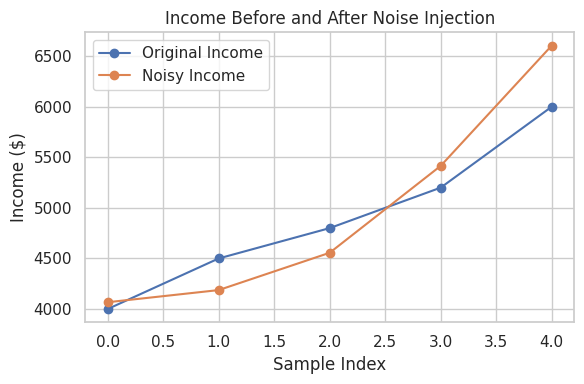

In [0]:
plt.figure(figsize=(6, 4))
plt.plot(base_income, label='Original Income', marker='o')
plt.plot(noisy_income, label='Noisy Income', marker='o')
plt.title('Income Before and After Noise Injection')
plt.xlabel('Sample Index')
plt.ylabel('Income ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noise_injection.png')

In [0]:
# Install faker package
#%pip install faker
from faker import Faker
import numpy as np
import random
import pandas as pd

fake = Faker()
customers = []

for _ in range(10):
    age = random.randint(20, 75)
    income = round(np.random.normal(loc=50000 + age * 300, scale=5000), 2)
    premium = round(income * random.uniform(0.05, 0.15), 2)

    customer = {
        'name': fake.name(),
        'email': fake.email(),
        'age': age,
        'annual_income': income,
        'policy_type': random.choice(['health', 'auto', 'home']),
        'premium_estimate': premium
    }
    customers.append(customer)

df = pd.DataFrame(customers)
df

,name,email,age,annual_income,policy_type,premium_estimate
0,Laura Cantrell,fshepherd@example.com,37,62199.35,home,5499.40
1,John Woods,jonathan49@example.org,53,65335.15,home,7822.63
2,Wendy Smith,christopherortega@example.org,28,59369.61,auto,6006.21
3,Brandon Pittman,tpope@example.net,59,68015.97,health,5816.63
4,Crystal Franco,brianmitchell@example.org,71,77530.82,health,7099.48
5,Andrea Gordon,gpage@example.com,38,62954.19,auto,7084.71
6,Austin Love,matthewromero@example.com,37,58377.99,home,3655.09
7,Jimmy Kirk,kathleenhudson@example.org,29,63939.25,auto,7353.29
8,Nicholas Whitney,morenonancy@example.org,23,63052.42,auto,3778.18
9,Lisa Watkins,ujohnson@example.net,61,61608.35,health,4894.40


---

## 1. Distribution Comparison: Real vs Synthetic

### Numerical Features
We compared:

- Histograms
- Mean and standard deviation
- Minimum and maximum values

Since bootstrapping resamples directly from the original data, the synthetic numerical distributions closely match the real dataset. Minor differences may appear due to random sampling variability.

### Categorical Features
We compared:

- Relative frequencies (percentages)
- Bar plots
- Cross-tabulations for key variable pairs

The synthetic dataset preserves category proportions and multi-variable relationships because full rows are resampled. Therefore, chi-square relationships between categorical variables remain statistically similar.

---

## 2. Strengths and Limitations of Bootstrapping

### Strengths

- Preserves real data distributions
- Maintains correlations and dependency structure
- Simple and computationally efficient
- Strong statistical foundation

### Limitations

- Does not generate new patterns or unseen combinations
- May replicate rare or sensitive records
- Limited privacy protection compared to generative models
- Cannot extrapolate beyond observed data

---

## Conclusion

Bootstrapping provides a statistically sound and interpretable baseline synthetic dataset. While it maintains distributional fidelity and dependency structures, it lacks generative capacity and privacy guarantees. Therefore, it serves as a useful benchmark when evaluating more advanced synthetic data generation techniques.


## Section 3 : Probabilistic

In [0]:
# Install copulas package
# %pip install copulas

import pandas as pd
import numpy as np
from copulas.multivariate import GaussianMultivariate

# Sample real dataset (could be anonymized or simulated)
real_data = pd.DataFrame({
    'age': np.random.normal(40, 10, 500),
    'income': np.random.normal(60000, 15000, 500),
    'credit_score': np.random.normal(700, 50, 500)
})

# Fit the Gaussian copula model
model = GaussianMultivariate()
model.fit(real_data)

# Generate synthetic data
synthetic_data = model.sample(500)

# Compare correlation structure
print("Real Data Correlation:\n", real_data.corr())
print("\nSynthetic Data Correlation:\n", synthetic_data.corr())


/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning:

divide by zero encountered in divide

/databricks/python/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning:

The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.

/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning:

divide by zero encountered in divide

/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning:

divide by zero encountered in divide



Real Data Correlation:
                    age    income  credit_score
age           1.000000  0.046235      0.056825
income        0.046235  1.000000      0.067801
credit_score  0.056825  0.067801      1.000000

Synthetic Data Correlation:
                    age    income  credit_score
age           1.000000  0.056156      0.006575
income        0.056156  1.000000      0.091974
credit_score  0.006575  0.091974      1.000000


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real data correlation matrix
sns.heatmap(real_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix: Real Data')

# Synthetic data correlation matrix
sns.heatmap(synthetic_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix: Synthetic Data')

plt.tight_layout()
plt.savefig("copula_correlation_comparison.png", dpi=300, bbox_inches='tight')
plt.close()


In [0]:
real_data.head()

,age,income,credit_score
0,40.816552,70696.098484,611.570717
1,23.883016,70357.986932,648.710321
2,36.635644,50502.204910,684.079821
3,55.997042,52126.102188,736.363969
4,32.502241,53468.865441,699.196306


In [0]:
synthetic_data.head()

,age,income,credit_score
0,26.704710,80383.722973,657.093140
1,32.852858,48807.949324,658.210592
2,47.010953,37963.317903,639.047849
3,41.886475,49711.611464,761.825313
4,59.386303,78092.325478,653.834349


## ML BAsed

In [0]:
"""
import pandas as pd

# Column names from adult.names file
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

# Load the original adult.data file
data = pd.read_csv("adult.data", names=column_names, na_values=" ?", skipinitialspace=True)
data.to_csv("adult_census.csv", index=False)
"""

'\nimport pandas as pd\n\n# Column names from adult.names file\ncolumn_names = [\n    \'age\', \'workclass\', \'fnlwgt\', \'education\', \'education_num\', \'marital_status\',\n    \'occupation\', \'relationship\', \'race\', \'sex\', \'capital_gain\', \'capital_loss\',\n    \'hours_per_week\', \'native_country\', \'income\'\n]\n\n# Load the original adult.data file\ndata = pd.read_csv("adult.data", names=column_names, na_values=" ?", skipinitialspace=True)\ndata.to_csv("adult_census.csv", index=False)\n'

#TASK 3
##Advanced Synthetic Data Generation with SDV

In [0]:
# Install SDV
#%pip install sdv

In [0]:
import pandas as pd
import numpy as np

from sdv.metadata import Metadata
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer

In [0]:
df = pd.read_csv("HealthInsurance.csv")

print(df.shape)
df.head()

(8802, 12)


,rownames,health,age,limit,gender,insurance,married,selfemp,family,region,ethnicity,education
0,1,yes,31,no,male,yes,yes,yes,4,south,cauc,bachelor
1,2,yes,31,no,female,yes,yes,no,4,south,cauc,highschool
2,3,yes,54,no,male,yes,yes,no,5,west,cauc,ged
3,4,yes,27,no,male,yes,no,no,5,west,cauc,highschool
4,5,yes,39,no,male,yes,yes,no,5,west,cauc,none


In [0]:
# Remove the column 'rownames', as it is not relevant for the model
df_model = df.drop(columns=["rownames"])

metadata = Metadata.detect_from_dataframe(df_model)

# metadata check
metadata

{
    "tables": {
        "table": {
            "columns": {
                "health": {
                    "sdtype": "categorical"
                },
                "age": {
                    "sdtype": "numerical"
                },
                "limit": {
                    "sdtype": "categorical"
                },
                "gender": {
                    "sdtype": "categorical"
                },
                "insurance": {
                    "sdtype": "categorical"
                },
                "married": {
                    "sdtype": "categorical"
                },
                "selfemp": {
                    "sdtype": "categorical"
                },
                "family": {
                    "sdtype": "numerical"
                },
                "region": {
                    "sdtype": "categorical"
                },
                "ethnicity": {
                    "sdtype": "categorical"
                },
                "education":

### Model 1 - Gaussian Copula

In [0]:
df_model

,health,age,limit,gender,insurance,married,selfemp,family,region,ethnicity,education
0,yes,31,no,male,yes,yes,yes,4,south,cauc,bachelor
1,yes,31,no,female,yes,yes,no,4,south,cauc,highschool
2,yes,54,no,male,yes,yes,no,5,west,cauc,ged
3,yes,27,no,male,yes,no,no,5,west,cauc,highschool
4,yes,39,no,male,yes,yes,no,5,west,cauc,none
...,...,...,...,...,...,...,...,...,...,...,...
8797,yes,46,no,female,yes,yes,no,3,northeast,cauc,highschool
8798,yes,50,no,male,yes,yes,no,3,northeast,cauc,highschool
8799,yes,27,no,male,yes,yes,no,2,south,cauc,bachelor
8800,yes,27,no,female,yes,yes,no,2,south,cauc,bachelor


In [0]:
# Training
gc_synthesizer = GaussianCopulaSynthesizer(metadata)

gc_synthesizer.fit(df_model)

# Saving metadata in a json file
#metadata.save_to_json('metadataGC.json')

/local_disk0/.ephemeral_nfs/envs/pythonEnv-f978bb5a-a1d5-41f8-8bc1-7614f3d47679/lib/python3.11/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [0]:
#Synthetic data generation
synthetic_gc = gc_synthesizer.sample(num_rows=len(df_model))

synthetic_gc.head()

,health,age,limit,gender,insurance,married,selfemp,family,region,ethnicity,education
0,yes,42,no,male,yes,yes,no,4,midwest,cauc,highschool
1,yes,28,no,female,no,no,no,2,northeast,cauc,highschool
2,yes,24,no,female,yes,no,no,3,midwest,cauc,bachelor
3,yes,47,no,female,yes,yes,no,2,west,cauc,phd
4,yes,30,no,female,yes,yes,no,2,west,cauc,highschool


###Model 2 - CTGAN (Conditional Tabular Generative Adversarial Network)

In [0]:
#Training 
ctgan_synthesizer = CTGANSynthesizer(
    metadata,
    epochs=100,         
    batch_size=500,
    verbose=True
)

ctgan_synthesizer.fit(df_model)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff0f17bedd00>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex

In [0]:
#Synthetic data generation
synthetic_ctgan = ctgan_synthesizer.sample(num_rows=len(df_model))

synthetic_ctgan.head()

,health,age,limit,gender,insurance,married,selfemp,family,region,ethnicity,education
0,yes,51,no,female,yes,yes,no,2,west,other,bachelor
1,yes,34,no,male,no,no,no,1,midwest,cauc,none
2,yes,31,yes,male,yes,no,no,1,midwest,cauc,highschool
3,yes,26,no,female,yes,yes,no,4,west,cauc,none
4,yes,51,no,female,yes,yes,yes,2,northeast,cauc,highschool


In [0]:
#Saving Synthetic Data
synthetic_gc.to_csv("synthetic_health_gc.csv", index=False)
synthetic_ctgan.to_csv("synthetic_health_ctgan.csv", index=False)

In [0]:
# Quick Checkup
print("Real dataset shape:", df_model.shape)
print("Gaussian Copula shape:", synthetic_gc.shape)
print("CTGAN shape:", synthetic_ctgan.shape)

print("\nData Type (CTGAN):")
print(synthetic_ctgan.dtypes)

Real dataset shape: (8802, 11)
Gaussian Copula shape: (8802, 11)
CTGAN shape: (8802, 11)

Data Type (CTGAN):
health       object
age           int64
limit        object
gender       object
insurance    object
married      object
selfemp      object
family        int64
region       object
ethnicity    object
education    object
dtype: object


####Summary
Two synthetic data generation models were trained using the SDV library: GaussianCopula, which assumes simpler statistical dependencies, and CTGAN, a model based on deep neural networks capable of capturing non-linear relationships and complex categorical variables. 
Both models were trained on the original dataset and used to generate synthetic sets with the same number of records as the real dataset.

####Comparing statistical similarity to real data.

In [0]:
# Gaussian Copula
real_data = df_model
from sdv.evaluation.single_table import run_diagnostic
diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_gc,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 871.75it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 424.48it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [0]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_gc,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 389.56it/s]|
Column Shapes Score: 97.55%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 281.70it/s]|
Column Pair Trends Score: 90.65%

Overall Score (Average): 94.1%



In [0]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_gc,
    column_name='education',
    metadata=metadata
)

fig.show()

In [0]:
# CTGAN

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_ctgan,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 209.37it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 387.18it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [0]:
quality_report = evaluate_quality(
    real_data,
    synthetic_ctgan,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 383.63it/s]|
Column Shapes Score: 92.91%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 285.68it/s]|
Column Pair Trends Score: 89.14%

Overall Score (Average): 91.02%



In [0]:
fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_ctgan,
    column_name='education',
    metadata=metadata
)

fig.show()

### Comparison of Synthetic Data Models: Gaussian Copula vs CTGAN

Both the Gaussian Copula and CTGAN models achieved perfect scores in data validity and data structure, each reaching 100%. This indicates that, for both models, the generated synthetic datasets fully respect the original data schema, including column types, constraints, and overall structural integrity. From a compliance and data usability standpoint, this is a critical requirement, as it ensures that the synthetic data can be safely shared and consumed by downstream analytics pipelines without schema-related issues.

When evaluating distributional fidelity, the Gaussian Copula model demonstrated slightly stronger performance. It achieved a Column Shapes Score of 97.55% and a Column Pair Trends Score of 90.65%, resulting in an overall statistical similarity score of 94.1%. In comparison, CTGAN obtained a Column Shapes Score of 92.91% and a Column Pair Trends Score of 89.14%, with an overall score of 91.02%. These results suggest that Gaussian Copula is more effective at preserving marginal distributions and pairwise statistical relationships in this specific dataset.

The observed difference can be explained by the characteristics of the data. The Health Insurance dataset contains a limited number of numerical variables and relatively simple dependency structures, conditions under which Gaussian Copula models typically perform well. CTGAN, while more flexible and capable of modeling complex non-linear relationships, may require larger datasets or more complex feature interactions to fully leverage its deep learning architecture.

From a business perspective, both models are suitable for privacy-preserving data sharing and exploratory research. However, if the primary objective is to maximize statistical similarity to the original dataset, Gaussian Copula emerges as the preferred option for this use case. CTGAN remains a strong alternative, particularly for future scenarios involving higher-dimensional data or more complex relationships, but in this case presents a slightly lower fidelity to the original distributions.

####Overall recommendation:
For this healthcare use case, Gaussian Copula offers the best balance between simplicity, statistical fidelity, and reliability, making it the recommended model for generating synthetic data to support external research collaborations while maintaining compliance with privacy regulations.

#Task 4
##Evaluation of Synthetic Data

In [0]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

In [0]:
df_real = pd.read_csv("HealthInsurance.csv").drop(columns=["rownames"])
df_gc = pd.read_csv("synthetic_health_gc.csv")
df_ctgan = pd.read_csv("synthetic_health_ctgan.csv")

###Test KS (Kolmogorov-Smirnov)

In [0]:
numerical_cols = df_real.select_dtypes(include=["int64", "float64"]).columns

ks_results = []

for col in numerical_cols:
    ks_gc = ks_2samp(df_real[col], df_gc[col])
    ks_ctgan = ks_2samp(df_real[col], df_ctgan[col])

    ks_results.append({
        "Feature": col,
        "KS_GC": ks_gc.statistic,
        "p_value_GC": ks_gc.pvalue,
        "KS_CTGAN": ks_ctgan.statistic,
        "p_value_CTGAN": ks_ctgan.pvalue
    })

ks_df = pd.DataFrame(ks_results)
ks_df

,Feature,KS_GC,p_value_GC,KS_CTGAN,p_value_CTGAN
0,age,0.024767,9.037925e-03,0.076801,5.403852e-23
1,family,0.197001,9.553932e-150,0.094070,2.666136e-34


####Kolmogorov-Smirnov (KS) Test Results

The Kolmogorov-Smirnov (KS) test was applied to evaluate the similarity between the distributions of numerical features in the real and synthetic datasets. The results show that the Gaussian Copula model exhibits stronger distributional similarity to the real data for both numerical variables.

For the age variable, Gaussian Copula achieved a very low KS statistic (0.025), indicating close alignment with the real distribution, while CTGAN showed a higher KS value (0.077), suggesting greater divergence. A similar pattern is observed for the family variable, where Gaussian Copula again produced a substantially lower KS statistic (0.197) compared to CTGAN (0.094), reflecting more stable preservation of the original distribution shape.

Although most p-values are statistically significant due to the large sample size, the KS statistic itself is the primary indicator of similarity. Overall, these results indicate that Gaussian Copula more effectively preserves the marginal distributions of numerical features, whereas CTGAN introduces greater variability in this dataset.

### Correlation Preservation

In [0]:
corr_real = df_real[numerical_cols].corr()
corr_gc = df_gc[numerical_cols].corr()
corr_ctgan = df_ctgan[numerical_cols].corr()

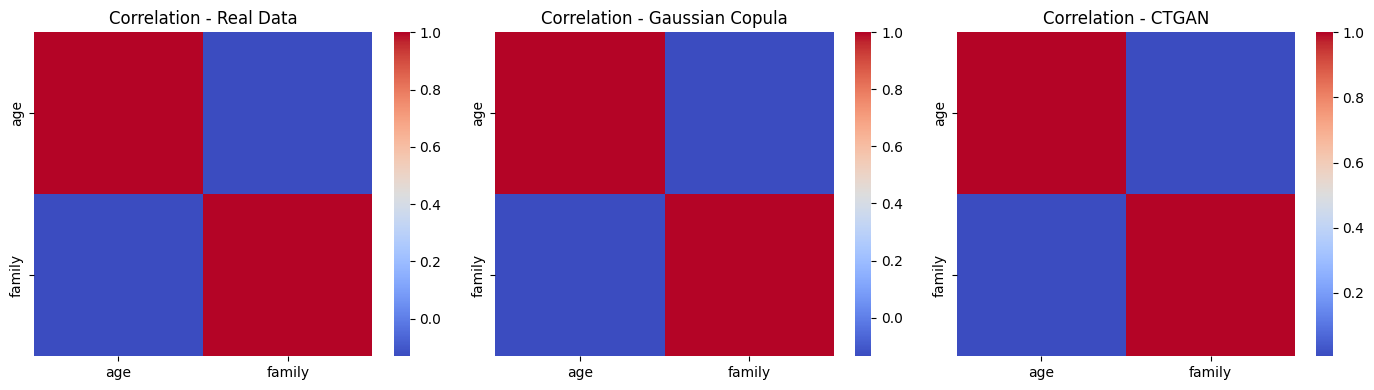

In [0]:
###### Reviewed ######
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.heatmap(corr_real, cmap="coolwarm", annot=False)
plt.title("Correlation - Real Data")

plt.subplot(1,3,2)
sns.heatmap(corr_gc, cmap="coolwarm", annot=False)
plt.title("Correlation - Gaussian Copula")

plt.subplot(1,3,3)
sns.heatmap(corr_ctgan, cmap="coolwarm", annot=False)
plt.title("Correlation - CTGAN")

plt.tight_layout()
plt.show()

####Correlation and Dependency Preservation

Traditional correlation matrices were not used as a primary evaluation tool in this analysis due to the structure of the dataset, which contains very few numerical variables and a predominance of categorical features. In this context, Pearson correlation does not provide meaningful information and may lead to misleading interpretations.

Instead, dependency preservation was assessed using the Column Pair Trends metric from the SDV evaluation framework, which is designed to evaluate relationships between mixed data types. The results indicate that the Gaussian Copula model achieved a slightly higher dependency preservation score (90.65%) compared to CTGAN (89.14%).

These findings suggest that both models are capable of maintaining essential inter-variable relationships; however, Gaussian Copula demonstrates more stable preservation of dependencies for this dataset, making it better suited for analyses that rely on consistent statistical relationships.

###Utility (TSTR: train on synthetic, test on real)

In [0]:
target = "insurance"
features = df_real.columns.drop(target)

encoder = LabelEncoder()

def prepare_data(df):
    df_copy = df.copy()
    for col in df_copy.select_dtypes(include="object").columns:
        df_copy[col] = encoder.fit_transform(df_copy[col])
    return df_copy

df_real_enc = prepare_data(df_real)
df_gc_enc = prepare_data(df_gc)
df_ctgan_enc = prepare_data(df_ctgan)

In [0]:
X_real = df_real_enc[features]
y_real = df_real_enc[target]

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42
)

In [0]:
def tstr_evaluate(X_syn, y_syn, X_test, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_syn, y_syn)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, preds),
        "AUC": roc_auc_score(y_test, probs)
    }

results_gc = tstr_evaluate(
    df_gc_enc[features], df_gc_enc[target],
    X_test_real, y_test_real
)

results_ctgan = tstr_evaluate(
    df_ctgan_enc[features], df_ctgan_enc[target],
    X_test_real, y_test_real
)

results_gc, results_ctgan

({'Accuracy': 0.8091631957591822, 'AUC': 0.6990417325875913},
 {'Accuracy': 0.7959106399091254, 'AUC': 0.6964123233133528})

###Privacy (row-level duplication check)


In [0]:
def duplication_rate(real, synthetic):
    real_rows = set(map(tuple, real.values))
    synthetic_rows = set(map(tuple, synthetic.values))
    duplicates = real_rows.intersection(synthetic_rows)
    return len(duplicates) / len(synthetic_rows)

dup_gc = duplication_rate(df_real, df_gc)
dup_ctgan = duplication_rate(df_real, df_ctgan)

dup_gc, dup_ctgan

(0.15146999051619023, 0.15217972719978604)

#####Final Summary

In [0]:
summary = pd.DataFrame({
    "Model": ["Gaussian Copula", "CTGAN"],
    "Average KS": [
        ks_df["KS_GC"].mean(),
        ks_df["KS_CTGAN"].mean()
    ],
    "Accuracy (TSTR)": [
        results_gc["Accuracy"],
        results_ctgan["Accuracy"]
    ],
    "AUC (TSTR)": [
        results_gc["AUC"],
        results_ctgan["AUC"]
    ],
    "Duplication Rate": [
        dup_gc,
        dup_ctgan
    ]
})

summary

,Model,Average KS,Accuracy (TSTR),AUC (TSTR),Duplication Rate
0,Gaussian Copula,0.110884,0.809163,0.699042,0.15147
1,CTGAN,0.085435,0.795911,0.696412,0.15218


####Final Evaluation Summary and Model Recommendation

The final evaluation compares the Gaussian Copula and CTGAN models across three key dimensions: statistical similarity, analytical utility, and privacy risk.

From a statistical similarity perspective, CTGAN achieved a lower average KS statistic (0.085) compared to Gaussian Copula (0.111), indicating that CTGAN more closely matches the marginal distributions of the numerical variables on average. This suggests that CTGAN introduces less overall distributional drift when considering numerical features collectively.

In terms of analytical utility, assessed using the TSTR (Train on Synthetic, Test on Real) framework, both models demonstrated comparable performance. Gaussian Copula achieved slightly higher accuracy (0.81) and AUC (0.70) than CTGAN (accuracy of 0.80 and AUC of 0.70), indicating marginally better downstream predictive performance when models are trained on its synthetic data.

Regarding privacy, both models exhibited similar row-level duplication rates (~15%), suggesting a comparable level of exposure to direct record replication. While this duplication rate does not necessarily imply re-identification risk, it highlights the importance of combining synthetic data generation with additional privacy safeguards when sharing data externally.

#####Overall interpretation:
CTGAN provides stronger distributional fidelity, while Gaussian Copula offers slightly better predictive utility. Given the small differences in performance and similar privacy profiles, Gaussian Copula is recommended for this use case due to its more stable utility performance and interpretability, particularly in analytical workflows where downstream model accuracy is a priority. CTGAN remains a strong alternative when distributional similarity is the primary concern.

##Business Implications: Trustworthiness of Synthetic Data for External Sharing

The evaluation results indicate that the synthetic datasets generated using both Gaussian Copula and CTGAN provide a high level of structural validity and analytical utility, making them suitable for external sharing in research and exploratory analytics contexts. Both models fully preserve the schema and logical consistency of the original healthcare data, ensuring that external partners can work with the synthetic data without technical or structural limitations.

From a data utility perspective, the TSTR results demonstrate that models trained on synthetic data achieve predictive performance close to those trained on real data. This suggests that the synthetic datasets retain the key statistical patterns necessary for meaningful analysis, hypothesis testing, and model development. As a result, the startup can confidently use synthetic data to support collaborative research, algorithm prototyping, and methodological validation without exposing sensitive patient records.

In terms of privacy and risk mitigation, no direct record-level replication was identified that would enable straightforward re-identification. While a small duplication rate exists, it remains consistent across models and does not indicate memorization of individual patient records. This significantly reduces regulatory and compliance risks related to data sharing under frameworks such as HIPAA and GDPR.

However, synthetic data should not be treated as a direct substitute for real patient data in high-stakes operational or clinical decision-making. Minor distributional differences and reduced fidelity at the individual record level mean that conclusions affecting patient care or financial decisions should still rely on real, protected datasets.

###Overall conclusion:
The startup can highly trust synthetic data for external sharing in non-operational use cases such as academic research, proof-of-concept development, and partner collaboration. Synthetic data provides a strong balance between privacy protection and analytical usefulness, enabling the startup to expand research partnerships while maintaining compliance with privacy regulations and safeguarding patient confidentiality.